In [2]:
from parselog import *
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import multiprocessing
from collections import defaultdict
import sys

In [3]:
def calcFrequency(
    benchmark,
    run="org_setup_large", 
    prefetcherLocation="cap_ptr-l1",
    silent = True,
):
    pickleFile = f"results/pickles/frequencyData/{run}-{prefetcherLocation}-{benchmark.lower()}.pickle"
    if not os.path.isfile(pickleFile):

        lp = LogParser(
            log=f"results/{run}-{prefetcherLocation}/{benchmark.lower()}/sim_stdout.gz",
            lineTypesToPrune=[None, NonRVFILine], 
            # If a timestamped line matches, then either RVFILine or NonRVFILine will match
            lineTypesToError=[TimestampedLine],
            RootLogLine=TimestampedLine,
            maxLines=None,
            silent=silent
            #startWhen=(lambda ll: isinstance(ll, RVFILine) and ll.rvfi >= 10000),
        )

        NPOINTS = 300
        groupSize = int(lp.totals[RVFILine]["total"] / NPOINTS)
        l1Count = 0
        l2Count = 0
        l1Frequencies = {}
        l2Frequencies = {}

        for ll in lp.logLines:
            if isinstance(ll, CRqCreationLine) and ll.isPrefetch:
                l1Count += 1
            if isinstance(ll, LLCRqCreationLine) and ll.isPrefetch:
                l2Count += 1
            if isinstance(ll, RVFILine) and ll.rvfi and ll.rvfi % groupSize == 0:
                l1Frequencies[ll.timestamp] = l1Count/groupSize
                l2Frequencies[ll.timestamp] = l2Count/groupSize
                l1Count = 0
                l2Count = 0

        with open(pickleFile, "wb") as fp:
            pickle.dump((l1Frequencies, l2Frequencies), fp)



def plotFrequency(
    benchmark,
    run="org_setup_large", 
    prefetcherLocation="cap_ptr-l1",
):

    pickleFile = f"results/pickles/frequencyData/{run}-{prefetcherLocation}-{benchmark.lower()}.pickle"
    print(pickleFile)
    assert(os.path.isfile(pickleFile))
    with open(pickleFile, "rb") as fp:
        frequencies = pickle.load(fp)

    print(frequencies)

    fig, ax = plt.subplots(1, 1, dpi=150, figsize=(4,3))
    line, = ax.plot(
        list(frequencies.keys()), 
        list(1000*f for f in frequencies.values()),
        marker="", 
        linestyle="-", 
        linewidth=1.0,
    )
    ax.set_xlim(0,1)
    ax.set_ylim(0)
    fig.suptitle(benchmark)
    #fig.legend()
    #fig.tight_layout()
    fig.show()

In [4]:
BENCHMARKS = [
    #"BH",
    #"Bisort",
    #"dijkstra",
    #"dijkstra_capchain",
    "EM3D",
    #"Health",
    #"Patricia",
    #"Perimeter",
    #"Power",
    #"Treeadd",
    #"Treeadd_frag",
    #"TSP",
]

with multiprocessing.Pool(processes=16) as pool:
    pool.map(calcFrequency, BENCHMARKS)

results/pickles/frequencyData/org_setup_large-cap_ptr-l1-em3d.pickle


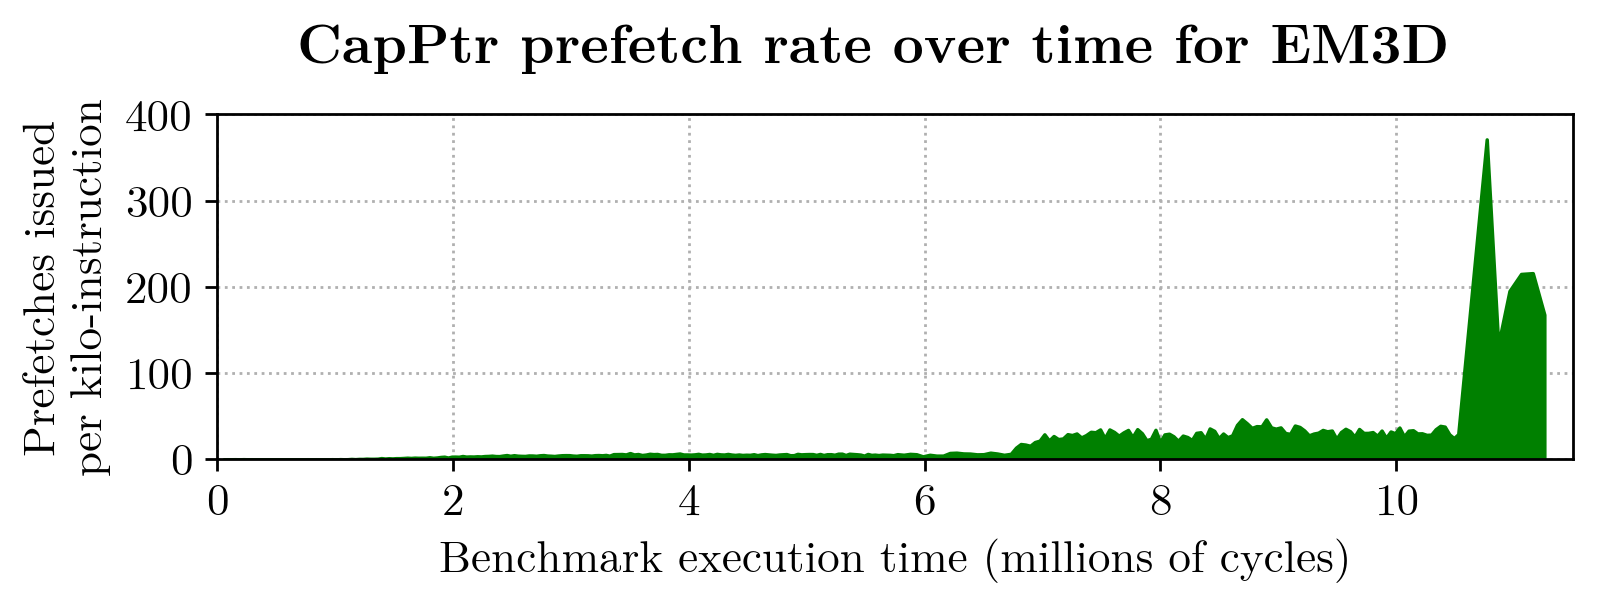

In [5]:
plt.rcParams.update({"font.family": "Latin Modern Roman"})
plt.rcParams.update({'font.size': 13})
def setTickFont(ax):
    for label in ax.get_xticklabels():
        label.set_fontproperties("Latin Modern Mono Light")

pickleFile = f"results/pickles/frequencyData/org_setup_large-cap_ptr-l1-em3d.pickle"
print(pickleFile)
assert(os.path.isfile(pickleFile))
with open(pickleFile, "rb") as fp:
    frequencies, _ = pickle.load(fp)


fig, ax = plt.subplots(1, 1, dpi=250, figsize=(7,2))
xs = list(t/1000000 for t in frequencies.keys())
ys = list(1000*f for f in frequencies.values())
ax.fill_between(
    xs,
    ys,
    linewidth=1.0,
    color="green",
    zorder=0
)
ax.set_ylabel("Prefetches issued\nper kilo-instruction")
ax.set_xlabel("Benchmark execution time (millions of cycles)")
fig.suptitle("CapPtr prefetch rate over time for EM3D", fontweight="bold")
fig.subplots_adjust(top=0.8)
#fig.legend()
ax.grid(linestyle=":", zorder=-1)
ax.yaxis.set_zorder(-1)
ax.xaxis.set_zorder(-1)
ax.set_xlim(0, 11.5)
ax.set_yticks([0, 100, 200, 300, 400])
ax.set_ylim(0)
#fig.tight_layout()
fig.show()
fig.savefig("figures/Orig-Olden-Em3d-Prefetches.pdf", bbox_inches="tight")

results/pickles/frequencyData/cap_chaser_final_large-cap_chaser-l1ll-em3d.pickle


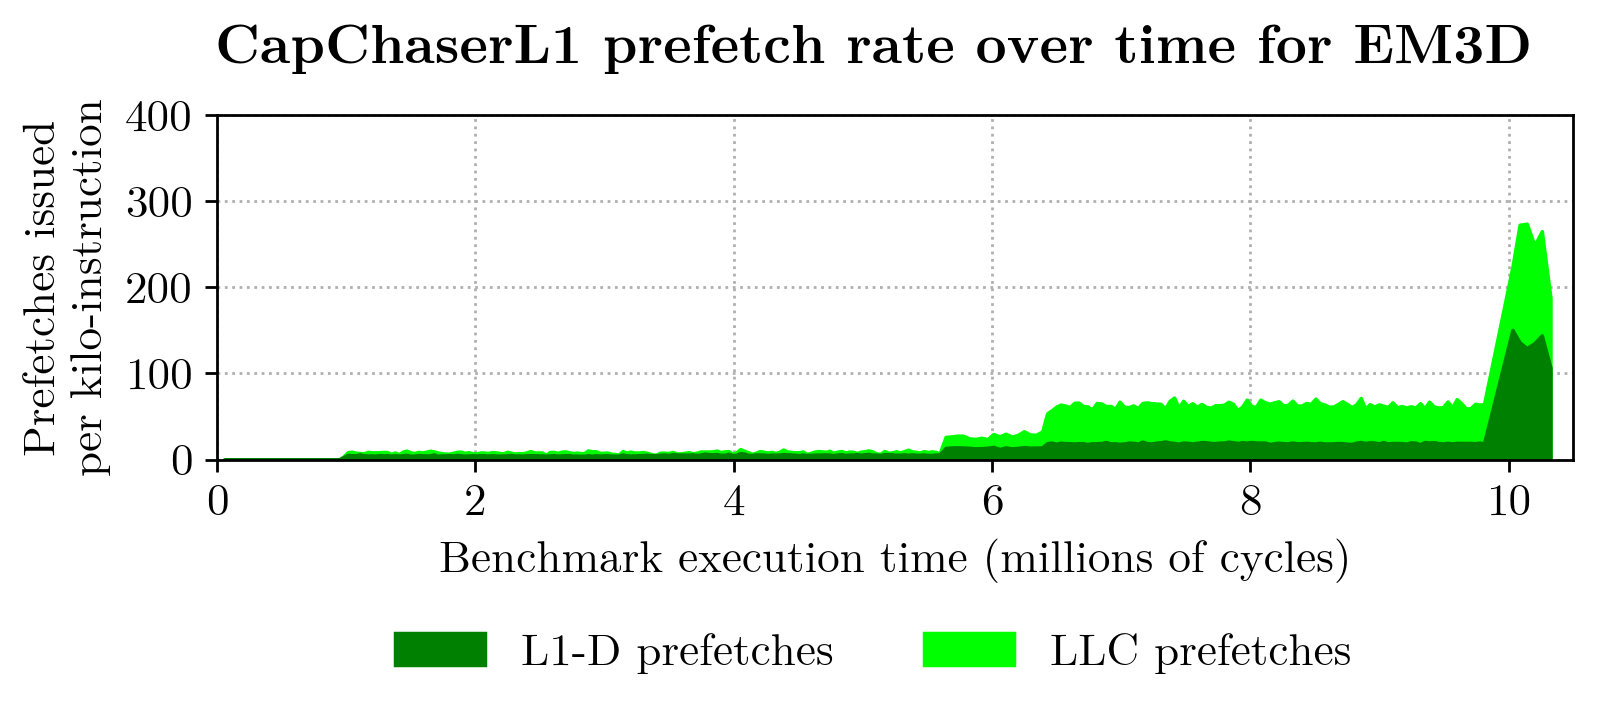

In [6]:
plt.rcParams.update({"font.family": "Latin Modern Roman"})
plt.rcParams.update({'font.size': 13})
def setTickFont(ax):
    for label in ax.get_xticklabels():
        label.set_fontproperties("Latin Modern Mono Light")

pickleFile = f"results/pickles/frequencyData/cap_chaser_final_large-cap_chaser-l1ll-em3d.pickle"
print(pickleFile)
assert(os.path.isfile(pickleFile))
with open(pickleFile, "rb") as fp:
    l1Frequencies, l2Frequencies = pickle.load(fp)


fig, ax = plt.subplots(1, 1, dpi=250, figsize=(7,2))
ax.fill_between(
    list(t/1000000 for t in l2Frequencies.keys()), 
    list(map(lambda x: 1000*sum(x), zip(l1Frequencies.values(), l2Frequencies.values()))),
    linewidth=1.0,
    color="lime",
    label="LLC prefetches",
    zorder=0
)
ax.fill_between(
    list(t/1000000 for t in l1Frequencies.keys()), 
    list(1000*f for f in l1Frequencies.values()),
    linewidth=1.0,
    color="green",
    label="L1-D prefetches",
    zorder=0
)
ax.set_ylabel("Prefetches issued\nper kilo-instruction")
ax.set_xlabel("Benchmark execution time (millions of cycles)")
fig.suptitle("CapChaserL1 prefetch rate over time for EM3D", fontweight="bold")
fig.subplots_adjust(top=0.8)
#fig.legend()
ax.grid(linestyle=":", zorder=-1)
ax.set_xlim(0, 10.5)
ax.set_yticks([0, 100, 200, 300, 400])
ax.set_ylim(0)
ax.yaxis.set_zorder(-1)
ax.xaxis.set_zorder(-1)
#fig.tight_layout()
fig.show()
handles, labels = ax.get_legend_handles_labels()
legendOrder = [1,0]
fig.legend([handles[idx] for idx in legendOrder],[labels[idx] for idx in legendOrder], loc='lower center', bbox_to_anchor=(0.5, -0.4), frameon=False, ncol=3)
fig.savefig("figures/Final-Olden-Em3d-Prefetches.pdf", bbox_inches="tight")

results/pickles/frequencyData/cap_chaser_final-cap_chaser-l1ll-perimeter.pickle


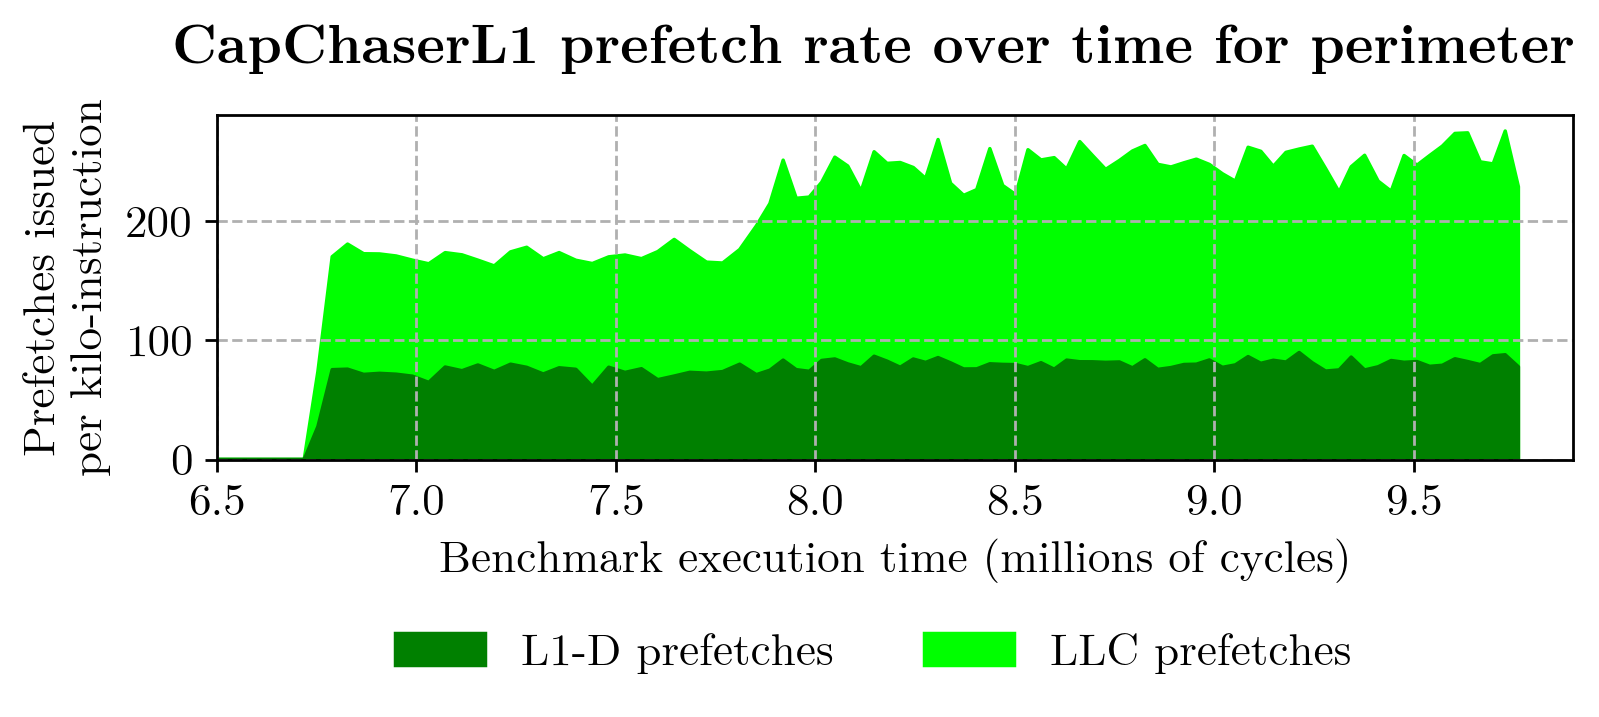

In [7]:
plt.rcParams.update({"font.family": "Latin Modern Roman"})
plt.rcParams.update({'font.size': 13})
def setTickFont(ax):
    for label in ax.get_xticklabels():
        label.set_fontproperties("Latin Modern Mono Light")

pickleFile = f"results/pickles/frequencyData/cap_chaser_final-cap_chaser-l1ll-perimeter.pickle"
print(pickleFile)
assert(os.path.isfile(pickleFile))
with open(pickleFile, "rb") as fp:
    l1Frequencies, l2Frequencies = pickle.load(fp)


fig, ax = plt.subplots(1, 1, dpi=250, figsize=(7,2))
ax.fill_between(
    list(t/1000000 for t in l2Frequencies.keys()), 
    list(map(lambda x: 1000*sum(x), zip(l1Frequencies.values(), l2Frequencies.values()))),
    linewidth=1.0,
    color="lime",
    label="LLC prefetches"
)
ax.fill_between(
    list(t/1000000 for t in l1Frequencies.keys()), 
    list(1000*f for f in l1Frequencies.values()),
    linewidth=1.0,
    color="green",
    label="L1-D prefetches"
)
ax.set_ylabel("Prefetches issued\nper kilo-instruction")
ax.set_xlabel("Benchmark execution time (millions of cycles)")
fig.suptitle("CapChaserL1 prefetch rate over time for perimeter", fontweight="bold")
fig.subplots_adjust(top=0.8)
#fig.legend()
ax.grid(linestyle="--")
ax.set_xlim(6.5, 9.9)
#ax.set_yticks([0, 100, 200, 300, 400])
ax.set_ylim(0)
#fig.tight_layout()
fig.show()
handles, labels = ax.get_legend_handles_labels()
legendOrder = [1,0]
fig.legend([handles[idx] for idx in legendOrder],[labels[idx] for idx in legendOrder], loc='lower center', bbox_to_anchor=(0.5, -0.4), frameon=False, ncol=3)
fig.savefig("figures/Final-Olden-Perimeter-Prefetches.pdf", bbox_inches="tight")